In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

import os
import random
import subprocess
import time
import warnings

import numpy as np
import librosa
import tensorflow as tf

from google.colab import drive
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

drive.mount("/content/drive")

print("Environment ready. Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready. Google Drive mounted.


# Namaste Tarang — Low-Latency Keyword Spotting for Edge Devices

This notebook documents the development of a lightweight keyword spotting model for the custom wake phrase **"Namaste Tarang"**, with deployment targeted toward resource-constrained edge devices such as the ESP32.

The pipeline covers:

- Audio preprocessing and MFCC feature extraction
- Group-aware dataset splitting
- Feature normalization
- Lightweight CNN training
- Model evaluation
- Decision-threshold analysis
- INT8 quantization
- TensorFlow Lite conversion
- Edge inference benchmarking

> **Note:** The training dataset is kept private and is not included in this repository.


In [2]:
# ============================================================
# 2. DATASET CONFIGURATION
# ============================================================

DATASET_DIR = "/content/drive/MyDrive/Audios"

positive_path = os.path.join(DATASET_DIR, "Positive")
negative_path = os.path.join(DATASET_DIR, "Negative")

print("Dataset directory configured.")

Dataset directory configured.


## 3. Audio Preprocessing & Feature Extraction

Audio is resampled to 16 kHz, trimmed for leading/trailing silence, padded or cropped to a fixed duration, and converted into 40-dimensional MFCC features.

In [3]:
# ============================================================
# AUDIO FEATURE EXTRACTION
# ============================================================

SR = 16000
FIXED_DURATION = 3.7
N_MFCC = 40

def extract_features(
    filepath,
    sr=SR,
    duration=FIXED_DURATION,
    n_mfcc=N_MFCC
):
    audio, _ = librosa.load(filepath, sr=sr)

    # Remove leading/trailing silence
    audio, _ = librosa.effects.trim(audio, top_db=20)

    # Fixed-length audio
    target_len = int(sr * duration)

    if len(audio) < target_len:
        audio = np.pad(
            audio,
            (0, target_len - len(audio))
        )
    else:
        audio = audio[:target_len]

    # MFCC extraction
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=400,
        hop_length=160
    )

    return mfcc

print(
    f"Audio configuration: {SR} Hz | "
    f"{FIXED_DURATION}s | {N_MFCC} MFCCs"
)

Audio configuration: 16000 Hz | 3.7s | 40 MFCCs


In [4]:
# ============================================================
# CONVERT AUDIO TO WAV CACHE
# ============================================================

def convert_to_wav_cache(source_folder, dest_folder):
    os.makedirs(dest_folder, exist_ok=True)

    files = [
        f for f in os.listdir(source_folder)
        if not f.startswith(".")
    ]

    converted = 0
    skipped_existing = 0

    for fname in files:
        out_name = os.path.splitext(fname)[0] + ".wav"
        out_path = os.path.join(dest_folder, out_name)
        in_path = os.path.join(source_folder, fname)

        if os.path.exists(out_path):
            skipped_existing += 1
            continue

        temp_webm = "/content/temp_convert.webm"
        temp_wav = "/content/temp_convert.wav"

        try:
            subprocess.run(
                [
                    "ffmpeg", "-y",
                    "-i", in_path,
                    "-c:a", "libopus",
                    "-b:a", "128k",
                    temp_webm
                ],
                capture_output=True
            )

            subprocess.run(
                ["ffmpeg", "-y", "-i", temp_webm, temp_wav],
                capture_output=True
            )

            subprocess.run(
                ["cp", temp_wav, out_path],
                check=True
            )

            converted += 1

        except Exception as e:
            print(f"Failed on {fname}: {e}")

    print(
        f"{dest_folder}: "
        f"{converted} newly converted, "
        f"{skipped_existing} already cached"
    )

In [5]:
# ============================================================
# CONVERT DATASET SOURCES
# ============================================================

folder_pairs = [
    (
        positive_path,
        os.path.join(DATASET_DIR, "Positive_wav")
    ),
    (
        negative_path,
        os.path.join(DATASET_DIR, "Negative_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Positive_augmented"),
        os.path.join(DATASET_DIR, "Positive_augmented_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_augmented"),
        os.path.join(DATASET_DIR, "Negative_augmented_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_public"),
        os.path.join(DATASET_DIR, "Negative_public_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_speech"),
        os.path.join(DATASET_DIR, "Negative_speech_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_hard"),
        os.path.join(DATASET_DIR, "Negative_hard_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Positive_mic"),
        os.path.join(DATASET_DIR, "Positive_mic_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Positive_mic_augmented"),
        os.path.join(DATASET_DIR, "Positive_mic_augmented_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_hard_augmented"),
        os.path.join(DATASET_DIR, "Negative_hard_augmented_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_hard_v2"),
        os.path.join(DATASET_DIR, "Negative_hard_v2_wav")
    ),
    (
        os.path.join(DATASET_DIR, "Negative_speech_mic"),
        os.path.join(DATASET_DIR, "Negative_speech_mic_wav")
    ),
]

for src, dst in folder_pairs:
    if os.path.exists(src):
        convert_to_wav_cache(src, dst)

/content/drive/MyDrive/Audios/Positive_wav: 0 newly converted, 323 already cached
/content/drive/MyDrive/Audios/Negative_wav: 0 newly converted, 53 already cached
/content/drive/MyDrive/Audios/Positive_augmented_wav: 0 newly converted, 504 already cached
/content/drive/MyDrive/Audios/Negative_augmented_wav: 0 newly converted, 318 already cached
/content/drive/MyDrive/Audios/Negative_public_wav: 0 newly converted, 349 already cached
/content/drive/MyDrive/Audios/Negative_speech_wav: 0 newly converted, 150 already cached
/content/drive/MyDrive/Audios/Negative_hard_wav: 0 newly converted, 161 already cached
/content/drive/MyDrive/Audios/Positive_mic_wav: 0 newly converted, 40 already cached
/content/drive/MyDrive/Audios/Positive_mic_augmented_wav: 0 newly converted, 160 already cached
/content/drive/MyDrive/Audios/Negative_hard_augmented_wav: 0 newly converted, 483 already cached
/content/drive/MyDrive/Audios/Negative_hard_v2_wav: 0 newly converted, 47 already cached
/content/drive/MyDriv

## 4. Dataset Preparation

The dataset combines positive wake-word samples with multiple categories of negative examples, including real speech, augmented samples, hard negatives, public negative samples, and microphone-specific recordings.

Augmented samples are grouped with their original recordings to prevent closely related samples from appearing in both training and validation sets.

In [6]:
# ============================================================
# DATASET SOURCES
# ============================================================

sources = {
    "Positive": (
        os.path.join(DATASET_DIR, "Positive_wav"), 1
    ),
    "Positive_augmented": (
        os.path.join(DATASET_DIR, "Positive_augmented_wav"), 1
    ),
    "Negative_real": (
        os.path.join(DATASET_DIR, "Negative_wav"), 0
    ),
    "Negative_augmented": (
        os.path.join(DATASET_DIR, "Negative_augmented_wav"), 0
    ),
    "Negative_public": (
        os.path.join(DATASET_DIR, "Negative_public_wav"), 0
    ),
    "Negative_speech": (
        os.path.join(DATASET_DIR, "Negative_speech_wav"), 0
    ),
    "Negative_hard": (
        os.path.join(DATASET_DIR, "Negative_hard_wav"), 0
    ),
    "Positive_mic": (
        os.path.join(DATASET_DIR, "Positive_mic_wav"), 1
    ),
    "Positive_mic_augmented": (
        os.path.join(DATASET_DIR, "Positive_mic_augmented_wav"), 1
    ),
    "Negative_extra_wav": (
        os.path.join(DATASET_DIR, "Negative_extra_wav"), 0
    ),
    "Negative_hard_augmented": (
        os.path.join(DATASET_DIR, "Negative_hard_augmented_wav"), 0
    ),
    "Negative_hard_v2": (
        os.path.join(DATASET_DIR, "Negative_hard_v2_wav"), 0
    ),
    "Negative_speech_mic": (
        os.path.join(DATASET_DIR, "Negative_speech_mic_wav"), 0
    ),
}

print("Dataset sources configured:", len(sources))

Dataset sources configured: 13


In [7]:
# ============================================================
# LOAD FEATURES AND LABELS
# ============================================================

random.seed(42)

MAX_PUBLIC_NEGATIVES = 200

X, y, groups = [], [], []
skipped = []
counts = {}

for label_name, (folder, label) in sources.items():

    if not os.path.exists(folder):
        print(f"Warning: folder not found -> {folder}")
        continue

    files = os.listdir(folder)

    if (
        label_name == "Negative_public"
        and len(files) > MAX_PUBLIC_NEGATIVES
    ):
        files = random.sample(
            files,
            MAX_PUBLIC_NEGATIVES
        )

    counts[label_name] = 0

    for fname in files:
        try:
            filepath = os.path.join(folder, fname)

            feat = extract_features(filepath)

            X.append(feat)
            y.append(label)
            counts[label_name] += 1

            if label_name == "Negative_augmented":
                base_id = fname.split("_aug")[0]
                groups.append(f"negreal_{base_id}")

            elif label_name == "Positive_augmented":
                base_id = fname.split("_aug")[0]
                groups.append(f"posreal_{base_id}")

            elif label_name == "Positive_mic_augmented":
                base_id = fname.split("_aug")[0]
                groups.append(f"posmic_{base_id}")

            elif label_name == "Negative_hard_augmented":
                base_id = fname.split("_aug")[0]
                groups.append(f"neghard_{base_id}")

            elif label_name == "Negative_hard_v2":
                groups.append(f"neghardv2_{fname}")

            elif label_name == "Positive_mic":
                groups.append(f"posmic_{fname}")

            elif label_name == "Negative_real":
                groups.append(f"negreal_{fname}")

            elif label_name == "Positive":
                groups.append(f"posreal_{fname}")

            elif label_name == "Negative_hard":
                groups.append(f"neghard_{fname}")

            elif label_name == "Negative_speech_mic":
                groups.append(f"negspeechmic_{fname}")

            else:
                groups.append(f"{label_name}_{fname}")

        except Exception as e:
            skipped.append(
                (label_name, fname, str(e))
            )

X = np.array(X)[..., np.newaxis]
y = np.array(y)
groups = np.array(groups)

print("\nFinal counts by source:")
for name, count in counts.items():
    print(f"{name}: {count}")

print("\nTotal positive:", np.sum(y == 1))
print("Total negative:", np.sum(y == 0))
print("Feature shape:", X.shape)
print("Labels shape:", y.shape)
print("Skipped files:", len(skipped))


Final counts by source:
Positive: 314
Positive_augmented: 504
Negative_real: 53
Negative_augmented: 318
Negative_public: 200
Negative_speech: 150
Negative_hard: 161
Positive_mic: 40
Positive_mic_augmented: 160
Negative_extra_wav: 110
Negative_hard_augmented: 483
Negative_hard_v2: 47
Negative_speech_mic: 8

Total positive: 1018
Total negative: 1530
Feature shape: (2548, 40, 371, 1)
Labels shape: (2548,)
Skipped files: 0


## 5. Grouped Train–Validation Split

A group-aware split is used so that original recordings and their augmented versions remain in the same partition. This reduces the risk of data leakage between training and validation sets.

In [8]:
# ============================================================
# GROUP-AWARE TRAIN / VALIDATION SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

input_shape = X_train.shape[1:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print(
    "Train pos/neg:",
    np.sum(y_train == 1),
    np.sum(y_train == 0)
)

print(
    "Validation pos/neg:",
    np.sum(y_val == 1),
    np.sum(y_val == 0)
)

print("Input shape:", input_shape)

Train shape: (2041, 40, 371, 1)
Validation shape: (507, 40, 371, 1)
Train pos/neg: 837 1204
Validation pos/neg: 181 326
Input shape: (40, 371, 1)


## 6. MFCC Normalization

Normalization statistics are calculated using the training set only and then applied to both training and validation data.

In [9]:
# ============================================================
# MFCC NORMALIZATION
# ============================================================

mfcc_mean = X_train.mean(
    axis=(0, 2),
    keepdims=True
)

mfcc_std = (
    X_train.std(
        axis=(0, 2),
        keepdims=True
    ) + 1e-6
)

X_train_norm = (
    X_train - mfcc_mean
) / mfcc_std

X_val_norm = (
    X_val - mfcc_mean
) / mfcc_std

print("Normalized training shape:", X_train_norm.shape)
print("Normalized validation shape:", X_val_norm.shape)

Normalized training shape: (2041, 40, 371, 1)
Normalized validation shape: (507, 40, 371, 1)


## 7. Lightweight CNN Architecture

A compact convolutional architecture is used to reduce the computational and memory requirements of the keyword spotting model.

The network uses standard and depthwise-separable convolutions followed by global average pooling and a small dense classifier.

In [10]:
# ============================================================
# LIGHTWEIGHT CNN MODEL
# ============================================================

model = models.Sequential([
    layers.Input(shape=input_shape),

    # Block 1
    layers.Conv2D(
        8,
        (3, 3),
        strides=2,
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.SeparableConv2D(
        16,
        (3, 3),
        padding="same",
        activation="relu",
        depthwise_regularizer=regularizers.l2(1e-4),
        pointwise_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.SeparableConv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        depthwise_regularizer=regularizers.l2(1e-4),
        pointwise_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.25),

    layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 20, 186, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 186, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 93, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 10, 93, 16)     │           216 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 93, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 46, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 5, 46, 32)      │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 46, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,770 (6.91 KB)

 Trainable params: 1,658 (6.48 KB)

 Non-trainable params: 112 (448.00 B)

In [11]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.8475913621262459), np.int64(1): np.float64(1.2192353643966547)}


In [12]:
# ============================================================
# TARGETED SAMPLE WEIGHTING
# ============================================================

sample_weight = np.ones(len(y_train))

for i, group in enumerate(groups[train_idx]):

    sample_weight[i] = class_weights[y_train[i]]

    if "Negative_speech" in group:
        sample_weight[i] *= 2.0

print("Sample weighting configured.")

Sample weighting configured.


## 8. Model Training

The model is trained with early stopping and adaptive learning-rate reduction. A checkpoint stores the best validation-loss model during training.

In [13]:
# ============================================================
# MODEL TRAINING
# ============================================================

checkpoint = ModelCheckpoint(
    "/content/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    sample_weight=sample_weight,
    epochs=50,
    batch_size=32,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ],
    verbose=0
)

print(
    f"Training completed after "
    f"{len(history.history['loss'])} epochs."
)

print(
    f"Best validation loss: "
    f"{min(history.history['val_loss']):.4f}"
)

print(
    f"Best validation accuracy: "
    f"{max(history.history['val_accuracy']):.4f}"
)

Training completed after 50 epochs.
Best validation loss: 0.3700
Best validation accuracy: 0.8462


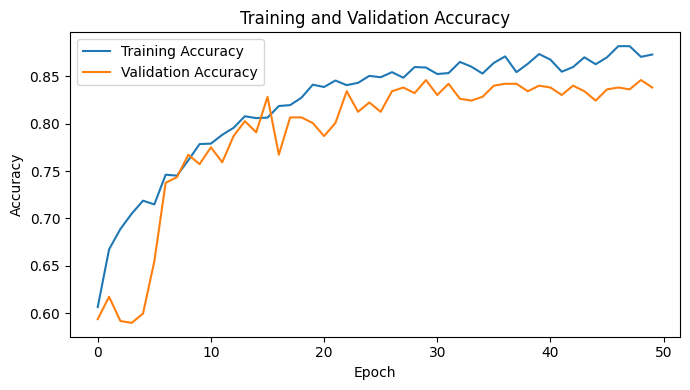

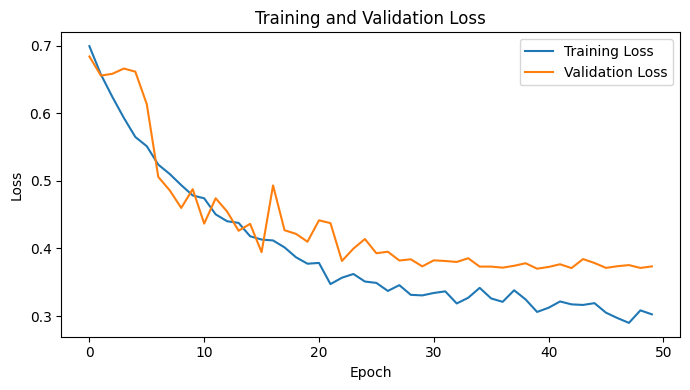

In [14]:
# ============================================================
# TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Evaluation

The trained model is evaluated on the held-out validation set using the confusion matrix and classification report.

In [15]:
# ============================================================
# MODEL EVALUATION
# ============================================================

y_pred_probs = model.predict(
    X_val_norm,
    verbose=0
)

y_pred = y_pred_probs.argmax(axis=1)

cm = confusion_matrix(
    y_val,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred,
        target_names=["not_wake", "wake"],
        digits=3
    )
)

Confusion Matrix:
[[288  38]
 [ 43 138]]

Classification Report:
              precision    recall  f1-score   support

    not_wake      0.870     0.883     0.877       326
        wake      0.784     0.762     0.773       181

    accuracy                          0.840       507
   macro avg      0.827     0.823     0.825       507
weighted avg      0.839     0.840     0.840       507



## 10. Threshold Analysis

Because false activations are important in a wake-word system, different wake-probability thresholds are evaluated to observe the trade-off between wake-word recall and false activations.

In [16]:
# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

wake_probs = y_pred_probs[:, 1]

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:

    y_pred_thresh = (
        wake_probs >= threshold
    ).astype(int)

    print(f"\n--- Threshold: {threshold:.1f} ---")

    print(
        classification_report(
            y_val,
            y_pred_thresh,
            target_names=["not_wake", "wake"],
            digits=3
        )
    )


--- Threshold: 0.5 ---
              precision    recall  f1-score   support

    not_wake      0.870     0.883     0.877       326
        wake      0.784     0.762     0.773       181

    accuracy                          0.840       507
   macro avg      0.827     0.823     0.825       507
weighted avg      0.839     0.840     0.840       507


--- Threshold: 0.6 ---
              precision    recall  f1-score   support

    not_wake      0.836     0.920     0.876       326
        wake      0.824     0.674     0.742       181

    accuracy                          0.832       507
   macro avg      0.830     0.797     0.809       507
weighted avg      0.832     0.832     0.828       507


--- Threshold: 0.7 ---
              precision    recall  f1-score   support

    not_wake      0.793     0.942     0.861       326
        wake      0.842     0.558     0.671       181

    accuracy                          0.805       507
   macro avg      0.817     0.750     0.766       507
we

In [17]:
# ============================================================
# INT8 TFLITE QUANTIZATION
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

def representative_dataset():
    for i in range(
        min(100, len(X_train_norm))
    ):
        yield [
            X_train_norm[i:i+1].astype(
                np.float32
            )
        ]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

TFLITE_PATH = os.path.join(
    DATASET_DIR,
    "kws_model.tflite"
)

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_kb = (
    os.path.getsize(TFLITE_PATH) / 1024
)

print(
    f"INT8 TFLite model size: "
    f"{size_kb:.2f} KB"
)

Saved artifact at '/tmp/tmpyu0ag_fy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 371, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134055452450960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452450768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452449616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452451344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452451728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452451536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452452304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452452112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452453456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452452496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134055452452688

## 11. Edge Inference Benchmark

The quantized TensorFlow Lite model is loaded using the TFLite interpreter and benchmarked over repeated inference runs.

In [18]:
# ============================================================
# TFLITE INFERENCE BENCHMARK
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=TFLITE_PATH
)

interpreter.allocate_tensors()

input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)

input_scale, input_zero_point = (
    input_details[0]["quantization"]
)

sample_float = X_val_norm[0:1].astype(
    np.float32
)

sample_input = np.round(
    sample_float / input_scale
    + input_zero_point
).astype(np.int8)

times = []

for _ in range(20):

    start = time.perf_counter()

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_input
    )

    interpreter.invoke()

    _ = interpreter.get_tensor(
        output_details[0]["index"]
    )

    times.append(
        (time.perf_counter() - start) * 1000
    )

print(
    f"Average TFLite inference time: "
    f"{np.mean(times):.2f} ms"
)

Average TFLite inference time: 0.72 ms


In [19]:
# ============================================================
# QUANTIZATION DETAILS
# ============================================================

print("INPUT")
print("dtype:", input_details[0]["dtype"])
print("shape:", input_details[0]["shape"])
print(
    "quantization:",
    input_details[0]["quantization"]
)

print("\nOUTPUT")
print("dtype:", output_details[0]["dtype"])
print("shape:", output_details[0]["shape"])
print(
    "quantization:",
    output_details[0]["quantization"]
)

INPUT
dtype: <class 'numpy.int8'>
shape: [  1  40 371   1]
quantization: (0.06912428140640259, -17)

OUTPUT
dtype: <class 'numpy.int8'>
shape: [1 2]
quantization: (0.00390625, -128)


## 13. Model Summary

The final pipeline produces a compact INT8 TensorFlow Lite keyword spotting model for the custom wake phrase **"Namaste Tarang"**.

The model is designed for edge deployment, with a lightweight CNN architecture, MFCC-based audio representation, and integer quantization for reduced model size and efficient inference.

### Reported metrics

The values below are generated automatically when the notebook is executed:

- Validation accuracy
- Wake-word precision
- Wake-word recall
- Wake-word F1-score
- INT8 model size
- TFLite inference time

The training dataset remains private and is not included in this repository.